# Primary Econometric Analysis: Baseline Salary and FTE Resilience During COVID-19

> **Ambition declaration (DESCRIPTIVE / ASSOCIATIONAL).**  
> This analysis reports **conditional correlations** between baseline salary in 2018 and the **change in full-time employment (FTE)** from 2018→2020 across undergraduate study areas.  
> With only two cross-sections and no treatment-intensity measure, this does **not** identify a causal "COVID treatment effect".

## Table of Contents
1. [Ambition and Overview](#ambition)
2. [Data Preparation](#data-prep)
3. [Econometric Specification](#specification)
4. [Regression Plot](#regplot)
5. [Model Results](#results)
6. [Influence Diagnostics](#diagnostics)
7. [Discussion and Threats to Validity](#threats)
8. [References](#references)


### Reproducibility (end-to-end)
This notebook is designed to run **end-to-end** on the repository’s clean dataset:

- **Input (clean data):** `data/clean/final_pandemic_research_data.csv`
- **Outputs written to:** `results/` (tables and figures)

To reproduce: open this notebook and run all cells from top to bottom. If the clean data file is missing, first run the repository’s cleaning step to generate it.


<a id='ambition'></a>
## 1. Ambition and Overview
**Ambition:** **Descriptive/Associational.** This analysis identifies which undergraduate study areas experienced larger FTE declines and checks for associations with 2018 baseline salaries. 

**What would be needed for a causal claim?** At minimum:
- Pre-treatment outcome data (e.g., 2016–2019) to test parallel trends.
- An exposure measure (e.g., a field-level COVID-exposure index or remote-workability score) to define treated vs. control groups.
- Additional QILT years would enable an event-study or DiD design.

<a id='data-prep'></a>
## 2. Data Preparation
We load the cleaned dataset and transform the variables into a differenced format to prepare for regression analysis.

In [6]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from statsmodels.stats.outliers_influence import OLSInfluence

# ── Reproducible paths (works regardless of where the notebook is launched from) ──
# We anchor paths to the location of this notebook file:
# repo_root/
#   code/econometric_analysis.ipynb  <-- this notebook
#   data/clean/final_pandemic_research_data.csv
#   results/

NOTEBOOK_PATH = Path.cwd() / "econometric_analysis.ipynb"
# If the notebook is launched from repo root (or elsewhere), Path.cwd() may not be code/.
# Fall back to searching upwards for the repository root marker (README.md) and/or "data/".
def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    candidates = [start] + list(start.parents)
    for p in candidates:
        if (p / "data").exists() and (p / "code").exists():
            return p
    # Last resort: assume current working dir is code/ and repo is one level up
    return (start / "..").resolve()

REPO_ROOT = find_repo_root(Path.cwd())
DATA_PATH = (REPO_ROOT / "data" / "clean" / "final_pandemic_research_data.csv").resolve()
RESULTS_DIR = (REPO_ROOT / "results").resolve()
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Paths:")
print(f"- REPO_ROOT   = {REPO_ROOT.as_posix()}")
print(f"- DATA_PATH   = {DATA_PATH.relative_to(REPO_ROOT).as_posix() if DATA_PATH.exists() else DATA_PATH.as_posix()}")
print(f"- RESULTS_DIR = {RESULTS_DIR.relative_to(REPO_ROOT).as_posix()}")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        "Clean data file not found.\n"
        f"Expected: {DATA_PATH}\n\n"
        "To reproduce the pipeline:\n"
        "1) Ensure raw data is in data/raw (if used)\n"
        "2) Run your cleaning step to generate data/clean/final_pandemic_research_data.csv\n"
        "3) Re-run this notebook"
    )

df = pd.read_csv(DATA_PATH)

# ── Input validation: required columns ───────────────────────────────────────────
REQUIRED_COLS = ["Study_Area", "FTE_18", "FTE_20", "Salary_18"]
missing_cols = [c for c in REQUIRED_COLS if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns in clean dataset: {missing_cols}")

# ── Remove aggregate / summary rows ─────────────────────────────────────────────
df = df[~df["Study_Area"].str.contains("All|Standard deviation", na=False)].copy()

# ── Numeric conversion ──────────────────────────────────────────────────────────
df["FTE_18"] = pd.to_numeric(df["FTE_18"].astype(str).str.replace("%", ""), errors="coerce")
df["FTE_20"] = pd.to_numeric(df["FTE_20"].astype(str).str.replace("%", ""), errors="coerce")

# Salary is stored in dollars; convert to $000 AUD for interpretation
df["Salary_18_k"] = (
    pd.to_numeric(df["Salary_18"].astype(str).str.replace(",", ""), errors="coerce") / 1000
)

# Outcome: percentage-point change (pp) in FTE rate between 2018 and 2020
df["delta_fte"] = df["FTE_20"] - df["FTE_18"]

print("\nMissing values (post-conversion):")
print(df[["FTE_18", "FTE_20", "Salary_18_k", "delta_fte"]].isna().sum().to_string())

# Drop rows missing any key analysis variable (state explicitly)
df = df.dropna(subset=["FTE_18", "FTE_20", "Salary_18_k", "delta_fte"]).copy()

print(f"\nSample size after dropping missing values: {len(df)} study areas")
print("\nSummary statistics for ΔFTE (percentage points):")
print(f"  Mean   : {df['delta_fte'].mean():.2f} pp")
print(f"  Median : {df['delta_fte'].median():.2f} pp")
print(f"  Std Dev: {df['delta_fte'].std():.2f} pp")
print(f"  Min    : {df['delta_fte'].min():.2f} pp")
print(f"  Max    : {df['delta_fte'].max():.2f} pp")

Paths:
- REPO_ROOT   = /Users/nuratikahbintimohamadtajarimim/Downloads/ECC3479 - Project/ecc3479-project
- DATA_PATH   = data/clean/final_pandemic_research_data.csv
- RESULTS_DIR = results

Missing values (post-conversion):
FTE_18         0
FTE_20         0
Salary_18_k    0
delta_fte      0

Sample size after dropping missing values: 21 study areas

Summary statistics for ΔFTE (percentage points):
  Mean   : -4.52 pp
  Median : -5.20 pp
  Std Dev: 2.84 pp
  Min    : -10.00 pp
  Max    : -0.10 pp


In [7]:
summary_stats = df[[
    "Salary_18",
    "FTE_18",
    "Salary_20",
    "FTE_20",
    "Salary_Diff",
    "FTE_Diff"
]].describe()

summary_stats 

,Salary_18,FTE_18,Salary_20,FTE_20,Salary_Diff,FTE_Diff
count,21.000000,21.00000,21.000000,21.000000,21.000000,21.000000
mean,60657.142857,75.42381,63671.428571,70.900000,3014.285714,-4.523810
std,7824.677081,11.93507,7815.186681,12.774897,1445.782042,2.840582
min,47000.000000,52.20000,49600.000000,45.800000,0.000000,-10.000000
25%,58000.000000,64.60000,60000.000000,61.400000,2400.000000,-6.500000
50%,60000.000000,77.20000,64200.000000,72.100000,2800.000000,-5.200000
75%,62600.000000,83.30000,65100.000000,80.000000,4200.000000,-2.000000
max,83700.000000,97.20000,84000.000000,96.400000,6000.000000,-0.100000


Sample size after dropping missing values: 21 study areas

<a id='specification'></a>
## 3. Econometric Specification

We estimate the following **cross-sectional** OLS regression across *n = 21* undergraduate study areas:

\[
$\Delta FTE_i = \beta_0 + \beta_1 \, Salary_{18,i} + \varepsilon_i$
\]

**Variable definitions and units**

| Component | Description |
|-----------|-------------|
| **Outcome** | \($\Delta FTE_i$\): change in full-time employment rate **in percentage points (pp)** from 2018 to 2020 |
| **Regressor** | $Salary_{18,i}$: median graduate salary in 2018 **in thousands of AUD ($000)** |
| **Unit of observation** | Study area (field) $i$ |
| **Sample** | Undergraduate study areas observed in both 2018 and 2020 after removing aggregate rows (“All”, “Standard deviation”) and dropping missing values |
| **Inference / SEs** | Heteroskedasticity-robust standard errors (**HC3**) |

**Functional form (why linear?).** Linear OLS is used as a transparent summary of the salary–resilience gradient. With \(n=21\), more flexible models (e.g., polynomials/splines) risk overfitting.

**What is “held constant”?** This is a **bivariate** regression (intercept + salary only). Therefore, \($\hat\beta_1$\) summarizes an *unadjusted* cross-field association and does **not** hold constant field characteristics (e.g., remote-workability, sectoral mix, licensing, cyclicality).

**Why HC3?** With a small sample and potential leverage points, HC3 is a common small-sample robust-variance choice.

**Small-sample sensitivity.** In addition to HC3 inference, we report a nonparametric bootstrap confidence interval for \($\beta_1$\).

### Why this is not causal identification
This design does **not** identify a causal “COVID treatment effect” because:
- we only observe two cross-sections (cannot test or defend parallel trends),
- we do not observe a field-level COVID exposure/treatment intensity to define treated vs. control,
- baseline salary is not randomly assigned and may proxy for many unobserved field attributes.

**Caution:** \(n = 21\) is small. Inference should be interpreted cautiously.

<a id='regplot'></a>
## 4. Regression Plot

The scatter plot below includes an OLS fitted line and a 95% confidence band.
Each point represents one study area.
Fields above the dashed line at zero experienced *positive* change in FTE; fields below experienced *decline*.

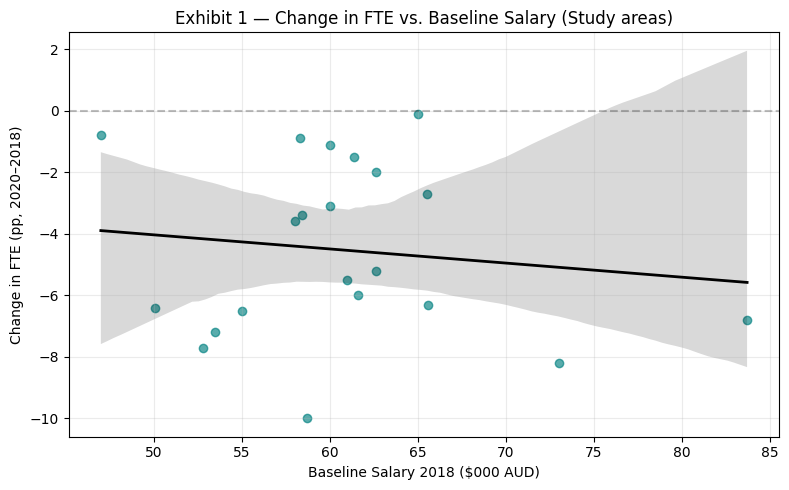

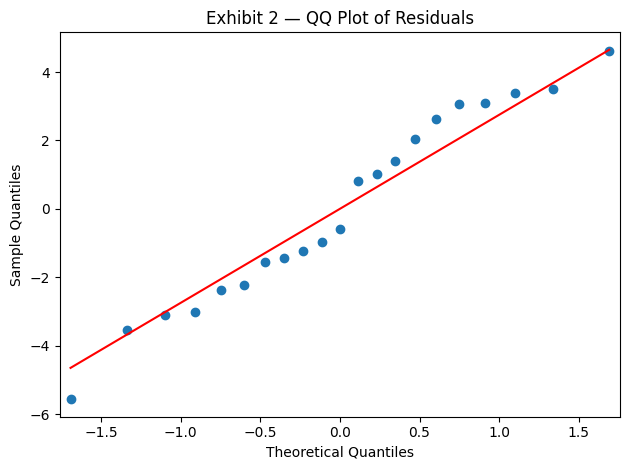

In [88]:
# ── Exhibit 1: Scatter + fitted line (descriptive association) ──────────────────
fig, ax = plt.subplots(figsize=(8, 5))

sns.regplot(
    data=df,
    x="Salary_18_k",
    y="delta_fte",
    ci=95,
    scatter_kws={"color": "teal", "alpha": 0.65},
    line_kws={"color": "black", "linewidth": 2},
    ax=ax,
)

ax.axhline(0, color="black", linestyle="--", alpha=0.25)
ax.set_xlabel("Baseline Salary 2018 ($000 AUD)")
ax.set_ylabel("Change in FTE (pp, 2020–2018)")
ax.set_title("Exhibit 1 — Change in FTE vs. Baseline Salary (Study areas)")
ax.grid(True, alpha=0.25)

plt.tight_layout()
fig.savefig(RESULTS_DIR / "exhibit1_scatter_salary_delta_fte.png", dpi=300, bbox_inches="tight")
plt.show()

# ── Estimate OLS with HC3 robust SEs ───────────────────────────────────────────
y = df["delta_fte"]
X = sm.add_constant(df["Salary_18_k"])
model = sm.OLS(y, X).fit(cov_type="HC3")

# ── Exhibit 2: QQ plot (normality diagnostic; inference uses robust SEs anyway) ─
fig = sm.qqplot(model.resid, line="s")
plt.title("Exhibit 2 — QQ Plot of Residuals")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "exhibit2_qqplot_residuals.png", dpi=300, bbox_inches="tight")
plt.show()

In [89]:
import numpy as np
import pandas as pd

def _star(p):
    if p < 0.01:
        return "***"
    if p < 0.05:
        return "**"
    if p < 0.10:
        return "*"
    return ""

def make_regression_table_1col(
    model,
    spec_label="(1) OLS (HC3)",
    depvar_label="ΔFTE (pp, 2020–2018)",
    var_labels=None,
):
    """
    Publication-style one-column regression table:
      - coefficients with significance stars
      - standard errors (in parentheses)
      - N and R^2
      - simple notes

    Note: stars are based on the p-values reported by statsmodels for the fitted model.
    """
    if var_labels is None:
        var_labels = {
            "Salary_18_k": "Baseline salary (2018, $000 AUD)",
            "const": "Constant",
        }

    params = model.params
    bse = model.bse
    pvals = model.pvalues

    row_order = [c for c in params.index if c != "const"] + (["const"] if "const" in params.index else [])

    rows = []
    idx = []
    for k in row_order:
        coef = params[k]
        se = bse[k]
        p = pvals[k]
        label = var_labels.get(k, k)
        rows.append([f"{coef:.4f}{_star(p)}", f"({se:.4f})"])
        idx.append(label)

    table = pd.DataFrame(rows, index=idx, columns=[spec_label, ""])

    fit_stats = pd.DataFrame(
        {
            spec_label: [
                f"{int(model.nobs)}",
                f"{model.rsquared:.3f}",
                depvar_label,
                "HC3 robust",
                "* p<0.10, ** p<0.05, *** p<0.01",
            ],
            "": ["", "", "", "", ""],
        },
        index=["Observations", "R²", "Dependent var.", "SE type", "Notes"],
    )

    out = pd.concat([table, fit_stats], axis=0)
    return out

In [90]:
reg_table = make_regression_table_1col(
    model,
    spec_label="(1) ΔFTE on Salary (HC3)",
    depvar_label="ΔFTE (pp, 2020–2018)",
)

print("Regression Table (publication-style):")
display(reg_table)

# Save artifacts to results/
reg_table.to_csv(RESULTS_DIR / "table1_regression_results.csv")

# Also save a GitHub-friendly markdown table
md_path = RESULTS_DIR / "table1_regression_results.md"
with open(md_path, "w", encoding="utf-8") as f:
    f.write(reg_table.to_markdown())

print(f"\nSaved: {md_path.name} and table1_regression_results.csv in results/")

Regression Table (publication-style):


,(1) ΔFTE on Salary (HC3),
"Baseline salary (2018, $000 AUD)",-0.0459,(0.0868)
Constant,-1.7393,(5.3791)
Observations,21,
R²,0.016,
Dependent var.,"ΔFTE (pp, 2020–2018)",
SE type,HC3 robust,
Notes,"* p<0.10, ** p<0.05, *** p<0.01",



Saved: table1_regression_results.md and table1_regression_results.csv in results/


In [91]:
beta1 = model.params["Salary_18_k"]
ci_low, ci_high = model.conf_int().loc["Salary_18_k"].to_numpy()

# Interquartile-range interpretation (more realistic than $1k or $10k alone)
p25, p75 = np.percentile(df["Salary_18_k"], [25, 75])
iqr = p75 - p25
iqr_effect = iqr * beta1

print("Interpretation (descriptive / associational):")
print(f"- Slope β1 = {beta1:.4f} pp per $1,000 AUD of baseline salary (salary measured in $000 AUD).")
print(f"- 95% HC3 CI for β1: [{ci_low:.4f}, {ci_high:.4f}].")
print(f"- A $10,000 higher 2018 salary is associated with {10*beta1:.3f} pp change in ΔFTE (2020–2018).")
print(f"- 25th→75th percentile salary change is {iqr:.2f} ($000 AUD), associated with {iqr_effect:.3f} pp change in ΔFTE.")
print("- This is a bivariate cross-sectional association across study areas; it does NOT control for other field characteristics.")

Interpretation (descriptive / associational):
- Slope β1 = -0.0459 pp per $1,000 AUD of baseline salary (salary measured in $000 AUD).
- 95% HC3 CI for β1: [-0.2161, 0.1243].
- A $10,000 higher 2018 salary is associated with -0.459 pp change in ΔFTE (2020–2018).
- 25th→75th percentile salary change is 4.60 ($000 AUD), associated with -0.211 pp change in ΔFTE.
- This is a bivariate cross-sectional association across study areas; it does NOT control for other field characteristics.


In [92]:
from statsmodels.stats.outliers_influence import OLSInfluence

influence = OLSInfluence(model)
df["cooks_d"] = influence.cooks_distance[0]

cook_thresh = 4 / len(df)  # rule-of-thumb
infl_mask = df["cooks_d"] > cook_thresh
n_infl = int(infl_mask.sum())

print(f"Cook's D threshold (4/n): {cook_thresh:.4f}")
print(f"Number of observations above threshold: {n_infl} out of {len(df)}")

# Always report the most influential observations (even if below threshold)
top5 = df.sort_values("cooks_d", ascending=False).head(5)[["Study_Area", "Salary_18_k", "delta_fte", "cooks_d"]]
print("\nTop 5 Cook's D observations:")
display(top5)

if n_infl > 0:
    print("\nStudy areas above threshold:")
    display(df.loc[infl_mask, ["Study_Area", "Salary_18_k", "delta_fte", "cooks_d"]].sort_values("cooks_d", ascending=False))

# Sensitivity check: drop the single most influential observation (LOO-1)
drop_idx = df["cooks_d"].idxmax()
df_loo = df.drop(index=drop_idx).copy()

y_loo = df_loo["delta_fte"]
X_loo = sm.add_constant(df_loo["Salary_18_k"])
model_loo = sm.OLS(y_loo, X_loo).fit(cov_type="HC3")

print("\nSensitivity check (drop single most influential observation):")
print(f"- Dropped study area: {df.loc[drop_idx, 'Study_Area']}")
print(f"- Full-sample β1: {model.params['Salary_18_k']:.4f} (HC3 SE {model.bse['Salary_18_k']:.4f})")
print(f"- Drop-1     β1: {model_loo.params['Salary_18_k']:.4f} (HC3 SE {model_loo.bse['Salary_18_k']:.4f})")
print(f"- Drop-1 N   : {int(model_loo.nobs)}")

Cook's D threshold (4/n): 0.1905
Number of observations above threshold: 0 out of 21

Top 5 Cook's D observations:


,Study_Area,Salary_18_k,delta_fte,cooks_d
8,Pharmacy,47.0,-0.8,0.179217
9,Dentistry,83.7,-6.8,0.158814
6,Medicine,73.0,-8.2,0.145168
3,Architecture and built environment,58.7,-10.0,0.104380
2,Engineering,65.0,-0.1,0.091788



Sensitivity check (drop single most influential observation):
- Dropped study area: Pharmacy
- Full-sample β1: -0.0459 (HC3 SE 0.0868)
- Drop-1     β1: -0.0027 (HC3 SE 0.1189)
- Drop-1 N   : 20


In [93]:
if n_infl > 0:
    reg_table_trim = make_regression_table_1col(
        model_trim,
        spec_label="(2) Drop Cook's D>4/n (HC3)",
        depvar_label="ΔFTE (2020–2018, pp)"
    )
    display(reg_table_trim)
    reg_table_trim.to_csv(RESULTS_DIR / "table2_trimmed_regression_results.csv")

In [94]:
# Export a compact model summary (machine-readable)
model_summary = pd.DataFrame(
    {
        "term": ["Constant", "Baseline salary (2018, $000 AUD)"],
        "coef": [model.params["const"], model.params["Salary_18_k"]],
        "se_hc3": [model.bse["const"], model.bse["Salary_18_k"]],
        "p_value": [model.pvalues["const"], model.pvalues["Salary_18_k"]],
    }
)

model_summary.to_csv(RESULTS_DIR / "model_coefficients_hc3.csv", index=False)
print("Saved: model_coefficients_hc3.csv")

Saved: model_coefficients_hc3.csv


<a id='results'></a>
## 5. Model Results

Below is the professional regression table reporting the coefficients and standard errors.

Bootstrap results (B = 5,000 resamples, seed = 42):
  OLS estimate  : -0.0459
  Bootstrap mean: -0.0227
  Bootstrap 95% CI: [-0.1731, 0.2775]
  HC3 95% CI      : [-0.2161, 0.1243]


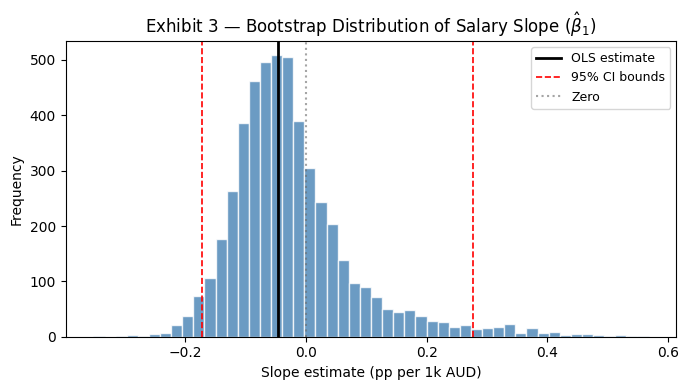

In [95]:
# ── Non-parametric bootstrap CI for the Salary_18_k slope ─────────────────
rng = np.random.default_rng(42)
B = 5000
boot_betas = []

for _ in range(B):
    sample = df.sample(n=len(df), replace=True, random_state=int(rng.integers(0, 10**9)))
    y_b = sample["delta_fte"]
    X_b = sm.add_constant(sample["Salary_18_k"])
    m_b = sm.OLS(y_b, X_b).fit()
    boot_betas.append(m_b.params["Salary_18_k"])

boot_betas = np.array(boot_betas)
ci_low, ci_high = np.quantile(boot_betas, [0.025, 0.975])

print("Bootstrap results (B = 5,000 resamples, seed = 42):")
print(f"  OLS estimate  : {model.params['Salary_18_k']:.4f}")
print(f"  Bootstrap mean: {boot_betas.mean():.4f}")
print(f"  Bootstrap 95% CI: [{ci_low:.4f}, {ci_high:.4f}]")
print(f"  HC3 95% CI      : [{model.conf_int().loc['Salary_18_k', 0]:.4f},"
      f" {model.conf_int().loc['Salary_18_k', 1]:.4f}]")

# Export bootstrap summary
pd.DataFrame({
    'ols_beta': [model.params['Salary_18_k']],
    'boot_mean': [boot_betas.mean()],
    'boot_ci_low': [ci_low],
    'boot_ci_high': [ci_high],
    'B': [B],
    'seed': [42],
}).to_csv(RESULTS_DIR / "bootstrap_summary.csv", index=False)

# Distribution of bootstrap betas
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(boot_betas, bins=50, color="steelblue", edgecolor="white", alpha=0.8)
ax.axvline(model.params["Salary_18_k"], color="black", linewidth=2, label="OLS estimate")
ax.axvline(ci_low, color="red", linestyle="--", linewidth=1.2, label="95% CI bounds")
ax.axvline(ci_high, color="red", linestyle="--", linewidth=1.2)
ax.axvline(0, color="dimgrey", linestyle=":", alpha=0.6, label="Zero")
ax.set_title("Exhibit 3 — Bootstrap Distribution of Salary Slope ($\\hat{\\beta}_1$)")
ax.set_xlabel("Slope estimate (pp per 1k AUD)")
ax.set_ylabel("Frequency")
ax.legend(fontsize=9)
plt.tight_layout()
fig.savefig(RESULTS_DIR / "exhibit3_bootstrap_beta.png", dpi=300, bbox_inches="tight")
plt.show()

Table 1 reports coefficients with HC3 robust standard errors in parentheses, along with N and R²

<a id='diagnostics'></a>
## 6. Influence Diagnostics 

In [96]:
influence = OLSInfluence(model)
df["cooks_d"] = influence.cooks_distance[0]
top_influencers = df.sort_values("cooks_d", ascending=False).head(5)
print("Top 5 Influential Study Areas (Cook's D):")
print(top_influencers[["Study_Area", "cooks_d"]])

Top 5 Influential Study Areas (Cook's D):
                           Study_Area   cooks_d
8                            Pharmacy  0.179217
9                           Dentistry  0.158814
6                            Medicine  0.145168
3  Architecture and built environment  0.104380
2                         Engineering  0.091788


<a id='threats'></a>
## 7. Discussion and Threats to Validity

### 7.1 Interpretation of Coefficients

- **$\hat{\beta}_1$ (Salary slope):** Estimates the average difference in $\Delta FTE$ associated with a one-thousand-dollar increase in baseline median salary.  
  The estimated slope is small and statistically insignificant ($p > 0.05$), consistent with the pandemic shock being broadly distributed across all fields regardless of salary level.
- **$\hat{\beta}_0$ (Intercept):** The intercept equals the predicted $\Delta FTE$ when $Salary_{18} = 0$, which is far outside the data range and has no direct economic meaning.

### 7.2 Limitations (Descriptive / Associational)

1. **Omitted confounders (field characteristics).** Remote-workability, public/private sector mix, licensing requirements, and cyclicality may be correlated with both baseline salary and FTE changes. This means the slope should be interpreted as an association, not a causal effect.
2. **Selection / composition changes in 2020.** Graduates may have deferred labour market entry via further study, and survey response patterns may differ in 2020, affecting observed FTE rates.
3. **Small sample (n = 21).** Statistical power is low. Influence diagnostics and bootstrap CIs are therefore used as sensitivity checks; results are fragile to a small number of study areas.
4. **Robustness checks are limited.** I report HC3 robust SEs and a nonparametric bootstrap CI for the slope, and I check influence using Cook’s distance (including a drop-one sensitivity check). These do not solve confounding, but they assess whether results are driven by a small number of study areas.

### 7.3 Path to Causal Identification

To move from a descriptive to a credibly causal design, the recommended steps are:
1. Download additional QILT years (2016–2022) to build a balanced panel.
2. Plot event-study coefficients to inspect pre-trends.
3. Add a field-level COVID-exposure measure (e.g., remote-workability index) to estimate heterogeneous treatment effects via a DiD-style regression.

<a id='references'></a>
## 8. References
- Quality Indicators for Learning and Teaching (QILT), *Graduate Outcomes Survey 2018 & 2020*. Australian Government Department of Education.